In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
summary_data = {}
summary_data["ceu"] = pd.read_csv("data/maf_causal/maf_causal_pop_ceu_all.csv")
summary_data["chb"] = pd.read_csv("data/maf_causal/maf_causal_pop_chb_all.csv")
summary_data["jpt"] = pd.read_csv("data/maf_causal/maf_causal_pop_jpt_all.csv")
summary_data["yri"] = pd.read_csv("data/maf_causal/maf_causal_pop_yri_all.csv")

In [4]:
def ecdf(x, xmax):
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / len(x)

    if x[-1] < xmax:
        x = np.append(x, xmax)
        y = np.append(y, 1.0)

    return x, y


C:\Users\daiki\AppData\Local\Temp\ipykernel_15900\3816935129.py:45: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\daiki\AppData\Local\Temp\ipykernel_15900\3816935129.py:46: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("allele-age-cdf.pdf")


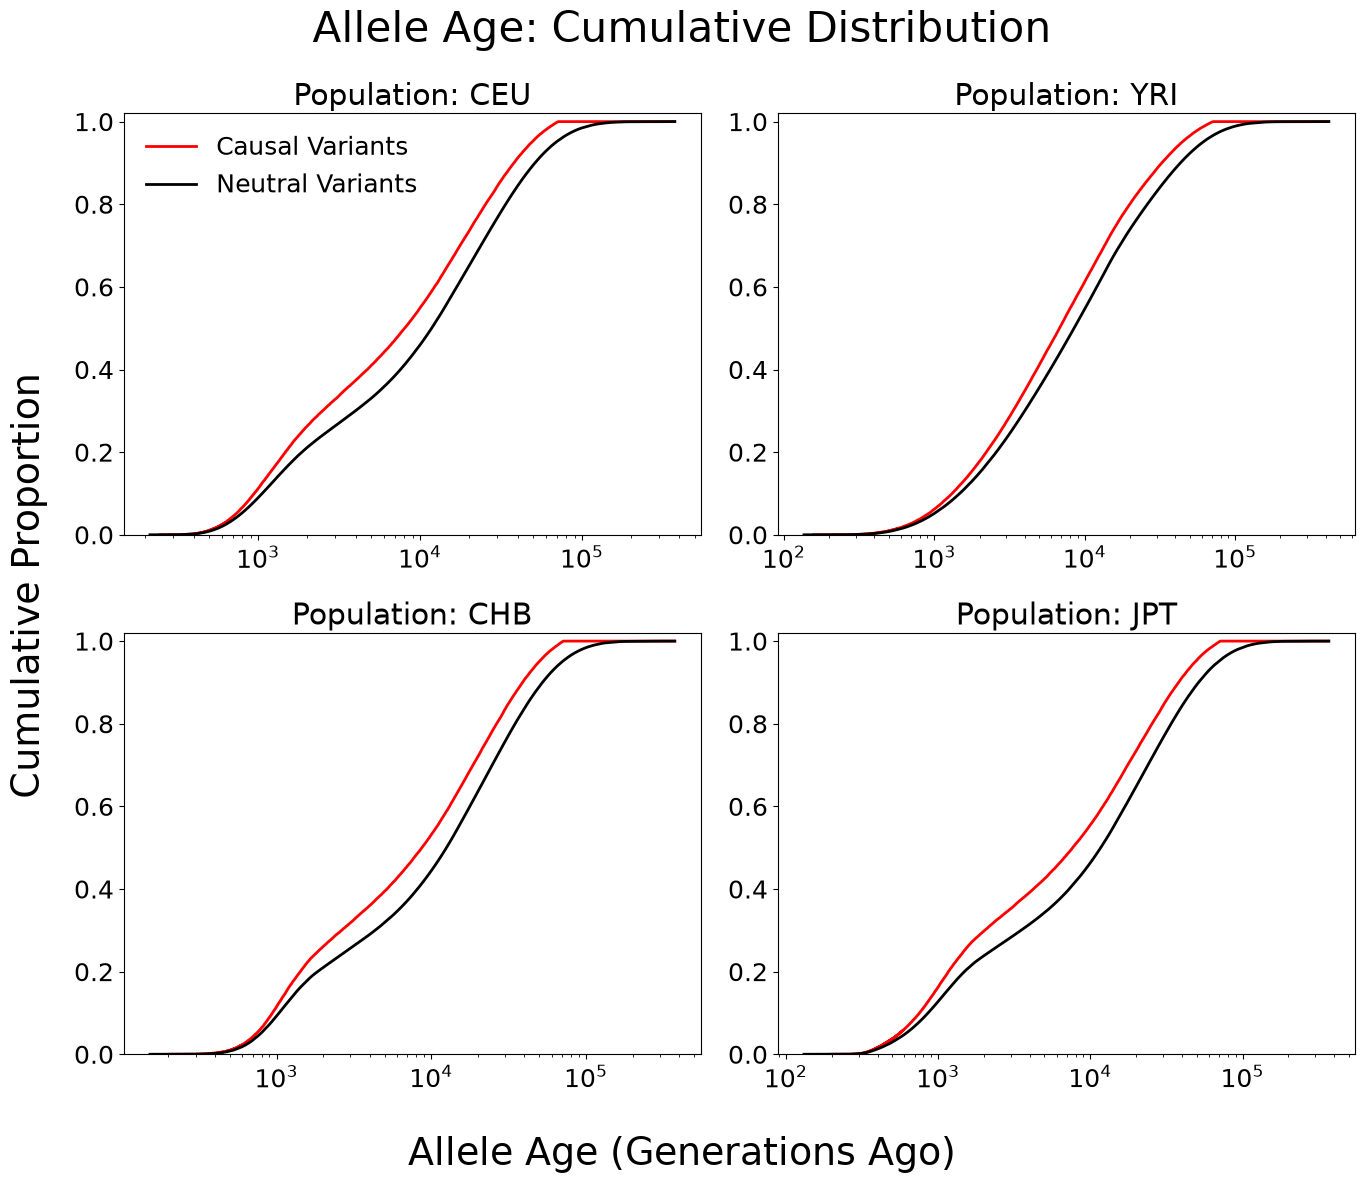

In [7]:
plt.rcParams.update({'font.size': 18})

fig = plt.figure(figsize=(14, 12))

for i, pop in enumerate(["ceu", "yri", "chb", "jpt"], 1):
    pop_df = summary_data[pop]

    causal_age = pop_df.loc[pop_df["causal"] == 1, "time"].to_numpy()
    background_age = pop_df.loc[pop_df["causal"] == 0, "time"].to_numpy()

    xmax = max(causal_age.max(), background_age.max())
    x_causal, y_causal = ecdf(causal_age, xmax)
    x_background, y_background = ecdf(background_age, xmax)

    ax = fig.add_subplot(2, 2, i)
    ax.plot(
        x_causal,
        y_causal,
        color="red",
        linewidth=2,
        label="Causal Variants",
    )
    
    ax.plot(
        x_background,
        y_background,
        color="black",
        linewidth=2,
        label="Neutral Variants",
    )
    
    ax.set_xscale("log")
    
    #ax.set_xlabel("Allele age (generations)")
    #ax.set_ylabel("Cumulative proportion")
    ax.set_title(f"Population: {pop.upper()}")
    ax.set_ylim(0, 1.02)
    
    if i == 1:
        ax.legend(frameon=False)

fig.suptitle("Allele Age: Cumulative Distribution", size=30)
fig.supxlabel("Allele Age (Generations Ago)", size=27)
fig.supylabel("Cumulative Proportion", size=27)
plt.tight_layout()
plt.savefig("allele-age-cdf.pdf")
plt.show()